In [1]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data

In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

In [3]:
# Predicting the typical time gap between each event
median_ttns = y_train.median() #Finding the typical inter-event time gap
y_predicted_median =[median_ttns]*len(y_test) #Median predicition for each event in the list
MAE_median = mean_absolute_error(y_test, y_predicted_median) #Comparing how the median prediction comapares to the ML methods using mean absolute error
Median_Error = MAE_median 
y_test_secs_median = y_test #Taking it out of log scale
y_pred_secs_median = [y for y in y_predicted_median]

absolute_error_secs_median = np.abs(y_pred_secs_median - y_test_secs_median)
print("MAE for Median:", np.mean(absolute_error_secs_median))

# Presistence baseline; assuming the TTNS is the same as the previous one
# Using an array where the first column is the TTNS from the previous event and the second column is the actual TTNS for the that event
y_test_array = y_test.values
y_predicted_presist = y_test_array[:-1]
y_actual = y_test_array[1:]

MAE_presist = mean_absolute_error(y_actual, y_predicted_presist)
Presist_Error = MAE_presist
print("MAE for Presistent:", Presist_Error)


Median_RMSE = root_mean_squared_error(y_test, y_predicted_median)
Median_Error = Median_RMSE
print("Median RMSE Error:", Median_Error)

Presist_RMSE = root_mean_squared_error(y_test[1:], y_predicted_presist)
Presist_Error = Presist_RMSE
print("Presist RMSE Error:", Presist_Error)

MAE for Median: 24078.182406209573
MAE for Presistent: 21619.896373056996
Median RMSE Error: 28840.040361277297
Presist RMSE Error: 28793.229379419303


Sample0: True = 53550.00s, Predicted = 51225.00s, Error=2325.00s
Sample1: True = 83610.00s, Predicted = 51225.00s, Error=32385.00s
Sample2: True = 93015.00s, Predicted = 51225.00s, Error=41790.00s
Sample3: True = 73710.00s, Predicted = 51225.00s, Error=22485.00s
Sample4: True = 55650.00s, Predicted = 51225.00s, Error=4425.00s
Sample5: True = 38625.00s, Predicted = 51225.00s, Error=12600.00s
Sample6: True = 73170.00s, Predicted = 51225.00s, Error=21945.00s
Sample7: True = 55140.00s, Predicted = 51225.00s, Error=3915.00s
Sample8: True = 40740.00s, Predicted = 51225.00s, Error=10485.00s
Sample9: True = 75480.00s, Predicted = 51225.00s, Error=24255.00s
Sample10: True = 83955.00s, Predicted = 51225.00s, Error=32730.00s
Sample11: True = 87045.00s, Predicted = 51225.00s, Error=35820.00s
Sample12: True = 86970.00s, Predicted = 51225.00s, Error=35745.00s
Sample13: True = 90210.00s, Predicted = 51225.00s, Error=38985.00s
Sample14: True = 30180.00s, Predicted = 51225.00s, Error=21045.00s
Sample15

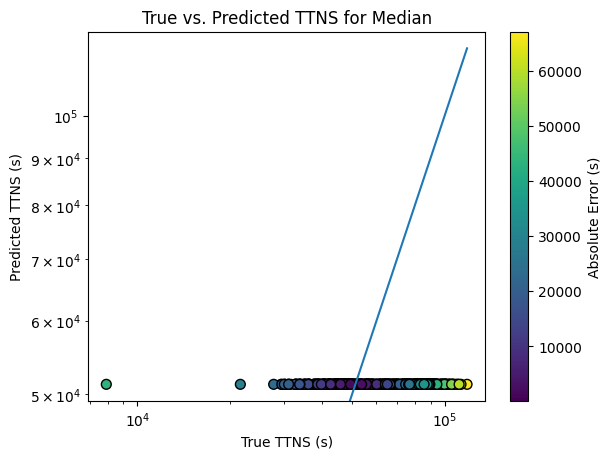

Sample0: True = 83610.00s, Predicted = 53550.00s, Error=30060.00s
Sample1: True = 93015.00s, Predicted = 83610.00s, Error=9405.00s
Sample2: True = 73710.00s, Predicted = 93015.00s, Error=19305.00s
Sample3: True = 55650.00s, Predicted = 73710.00s, Error=18060.00s
Sample4: True = 38625.00s, Predicted = 55650.00s, Error=17025.00s
Sample5: True = 73170.00s, Predicted = 38625.00s, Error=34545.00s
Sample6: True = 55140.00s, Predicted = 73170.00s, Error=18030.00s
Sample7: True = 40740.00s, Predicted = 55140.00s, Error=14400.00s
Sample8: True = 75480.00s, Predicted = 40740.00s, Error=34740.00s
Sample9: True = 83955.00s, Predicted = 75480.00s, Error=8475.00s
Sample10: True = 87045.00s, Predicted = 83955.00s, Error=3090.00s
Sample11: True = 86970.00s, Predicted = 87045.00s, Error=75.00s
Sample12: True = 90210.00s, Predicted = 86970.00s, Error=3240.00s
Sample13: True = 30180.00s, Predicted = 90210.00s, Error=60030.00s
Sample14: True = 57840.00s, Predicted = 30180.00s, Error=27660.00s
Sample15: Tr

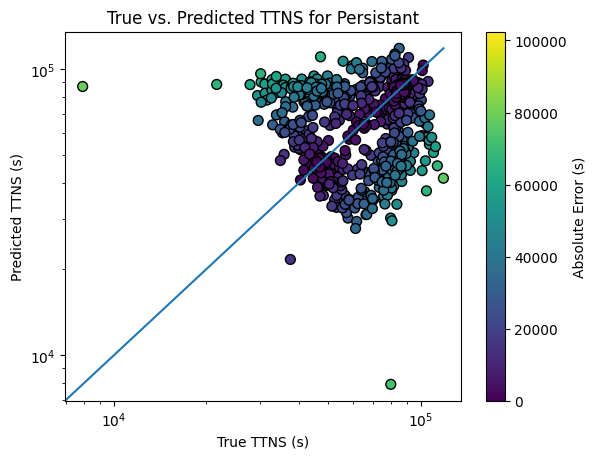

In [4]:
# Baseline Analysis:Median

y_test_secs = y_test #Taking it out of log scale
y_pred_secs = y_predicted_median

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Median")
plt.xscale('log')
plt.yscale('log')
plt.show()

#Persistnat 
y_test_secs = y_test[1:] #Taking it out of log scale
y_pred_secs = y_predicted_presist

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Persistant")
plt.xscale('log')
plt.yscale('log')
plt.show()